In [170]:
import pandas as pd  
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  

In [171]:
app_reviews_df = pd.read_csv('ulasan_aplikasi.csv')
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,55e6b801-9683-4126-9de1-7684539d9c23,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Ketika Saya bertanding, sesuatu terjadi. Analo...",2,4,2.1.61.11705,2026-04-08 22:46:01,NaN,NaN,2.1.61.11705
1,e1c85852-26e5-453e-9224-9db6a94a419a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"game paling sampah setelah ff, gw sbgai player...",1,3,2.1.61.11705,2026-04-12 12:05:52,NaN,NaN,2.1.61.11705
2,64da7393-7c68-4f4c-a60a-cb83d6f755ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Terungkap Developer..... Saya mungkin hanya sa...,2,9,2.1.61.11705,2026-03-29 04:49:46,"Halo Kak,\nKami berkomitmen untuk menciptakan ...",2026-03-29 10:06:41,2.1.61.11705
3,32903c9a-cd0a-42b2-ae40-f69bb1874c17,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sejujurnya main nih game ga harus yang gimana-...,3,3,2.1.61.11705,2026-04-12 20:22:49,NaN,NaN,2.1.61.11705
4,c76acefe-0fea-4757-8c6a-465803ea8b5d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gw sbgai player solo kecewa selalu dapat tim y...,1,2,2.1.61.11705,2026-04-17 09:49:39,NaN,NaN,2.1.61.11705


In [172]:
app_reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 225000 entries, 0 to 224999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   reviewId              225000 non-null  str  
 1   userName              225000 non-null  str  
 2   userImage             225000 non-null  str  
 3   content               224999 non-null  str  
 4   score                 225000 non-null  int64
 5   thumbsUpCount         225000 non-null  int64
 6   reviewCreatedVersion  173922 non-null  str  
 7   at                    225000 non-null  str  
 8   replyContent          9234 non-null    str  
 9   repliedAt             9234 non-null    str  
 10  appVersion            173922 non-null  str  
dtypes: int64(2), str(9)
memory usage: 18.9 MB


In [173]:
#menghapus baris yg memiliki nilai hilang dan menghapus baris duplikat
clear_df = app_reviews_df.dropna()
clear_df = clear_df.drop_duplicates()
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clear_df.shape

In [174]:
clear_df.info()

<class 'pandas.DataFrame'>
Index: 7496 entries, 2 to 224963
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   reviewId              7496 non-null   str  
 1   userName              7496 non-null   str  
 2   userImage             7496 non-null   str  
 3   content               7496 non-null   str  
 4   score                 7496 non-null   int64
 5   thumbsUpCount         7496 non-null   int64
 6   reviewCreatedVersion  7496 non-null   str  
 7   at                    7496 non-null   str  
 8   replyContent          7496 non-null   str  
 9   repliedAt             7496 non-null   str  
 10  appVersion            7496 non-null   str  
dtypes: int64(2), str(9)
memory usage: 702.8 KB


In [175]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
 
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
 
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text
 
def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text
 
def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text
 
def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text
 
def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
 
    # Memecah teks menjadi daftar kata
    words = text.split()
 
    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]
 
    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)
 
    return stemmed_text
 
def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [176]:
slangwords = {
    "@": "di",
    "abis": "habis",
    "wtb": "beli",
    "wts": "jual",
    "wtt": "tukar",
    "bgt": "banget",
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "tdk": "tidak",
    "kalo": "kalau",
    "klo": "kalau",
    "sm": "sama",
    "sma": "sama",
    "dr": "dari",
    "dri": "dari",
    "yg": "yang",
    "aja": "saja",
    "doang": "saja",
    "udh": "sudah",
    "udah": "sudah",
    "blm": "belum",
    "belom": "belum",
    "jd": "jadi",
    "jdi": "jadi",
    "krn": "karena",
    "krna": "karena",
    "karna": "karena",
    "tp": "tapi",
    "tpi": "tapi",
    "bgus": "bagus",
    "jelek banget": "sangat buruk",
    "mantul": "mantap betul",
    "mantap": "bagus",
    "parah": "sangat",
    "gila": "sangat",
    "anjir": "wow",
    "bjir": "wow",
    "buset": "wow",
    "wkwk": "tertawa",
    "wk": "tertawa",
    "haha": "tertawa",
    "lol": "tertawa",
    "fix": "pasti",
    "real": "nyata",
    "rill": "nyata",
    "asli": "benar",
    "cuy": "teman",
    "bro": "teman",
    "sis": "teman",
    "gan": "teman",
    "min": "admin",
    "mimin": "admin",
    "admin": "admin",
    "noob": "pemula",
    "pro": "ahli",
    "op": "terlalu kuat",
    "nerf": "lemahkan",
    "buff": "kuatkan"
}

def fix_slangwords(text):
    words = text.split()
    fixed_words = []
 
    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)
 
    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [177]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clear_df['text_clean'] = clear_df['content'].apply(cleaningText)
 
# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clear_df['text_casefoldingText'] = clear_df['text_clean'].apply(casefoldingText)
 
# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clear_df['text_slangwords'] = clear_df['text_casefoldingText'].apply(fix_slangwords)
 
# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clear_df['text_tokenizingText'] = clear_df['text_slangwords'].apply(tokenizingText)
 
# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clear_df['text_stopword'] = clear_df['text_tokenizingText'].apply(filteringText)
 
# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clear_df['text_akhir'] = clear_df['text_stopword'].apply(toSentence)

In [178]:
import csv
import requests
from io import StringIO
 
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()
 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")
 
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()
 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [ ]:
def sentiment_analysis_lexicon_indonesia(text):
 
    score = 0
    # Inisialisasi skor sentimen ke 0
 
    for word in text:
        # Mengulangi setiap kata dalam teks
 
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen
 
    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)
 
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen
 
    polarity=''
    # Inisialisasi variabel polaritas
 
    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [180]:
results = clear_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clear_df['polarity_score'] = results[0]
clear_df['polarity'] = results[1]
print(clear_df['polarity'].value_counts())

polarity
negative    4923
positive    2140
neutral      433
Name: count, dtype: int64


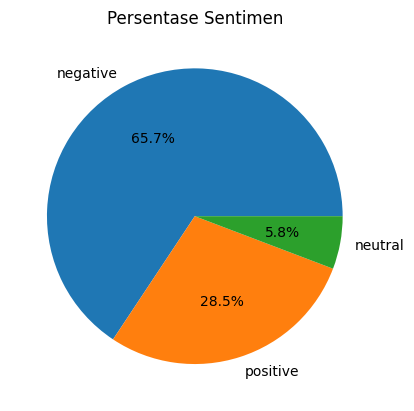

In [181]:
clear_df['polarity'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Persentase Sentimen')
plt.ylabel('')  
plt.show()

In [182]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

X = clear_df['text_akhir']
y = clear_df['polarity']

tfidf_1 = TfidfVectorizer(
    max_features=2000,
    min_df=5,
    max_df=0.75,
)

X_tfidf_1 = tfidf_1.fit_transform(X)

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_tfidf_1, y, test_size=0.2, random_state=42
)

model_svm = LinearSVC(C=0.5)
model_svm.fit(X_train_1, y_train_1)

y_pred_train_1 = model_svm.predict(X_train_1)
y_pred_test_1 = model_svm.predict(X_test_1)

print("=== Percobaan 1: LinearSVC ===")
print("Accuracy Train:", accuracy_score(y_train_1, y_pred_train_1))
print("Accuracy Test :", accuracy_score(y_test_1, y_pred_test_1))
print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_test_1))

=== Percobaan 1: LinearSVC ===
Accuracy Train: 0.9322881921280853
Accuracy Test : 0.8566666666666667

Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.95      0.91       968
     neutral       0.17      0.01      0.02        86
    positive       0.81      0.82      0.82       446

    accuracy                           0.86      1500
   macro avg       0.62      0.59      0.58      1500
weighted avg       0.82      0.86      0.83      1500



In [183]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_1, y_train_1)

y_pred_train = model_lr.predict(X_train_1)
y_pred_test = model_lr.predict(X_test_1)

print("=== Percobaan 2: Logistic Regression ===")
print("Accuracy Train:", accuracy_score(y_train_1, y_pred_train))
print("Accuracy Test :", accuracy_score(y_test_1, y_pred_test))
print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_test))

=== Percobaan 2: Logistic Regression ===
Accuracy Train: 0.8932621747831888
Accuracy Test : 0.854

Classification Report:


C:\Users\dodih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dodih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dodih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

              precision    recall  f1-score   support

    negative       0.86      0.96      0.91       968
     neutral       0.00      0.00      0.00        86
    positive       0.84      0.79      0.82       446

    accuracy                           0.85      1500
   macro avg       0.57      0.58      0.57      1500
weighted avg       0.80      0.85      0.83      1500



In [184]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

model_sgd = SGDClassifier(loss='hinge', random_state=42)
model_sgd.fit(X_train_1, y_train_1)

y_pred_train = model_sgd.predict(X_train_1)
y_pred_test = model_sgd.predict(X_test_1)

print("=== Percobaan 3: SGDClassifier ===")
print("Accuracy Train:", accuracy_score(y_train_1, y_pred_train))
print("Accuracy Test :", accuracy_score(y_test_1, y_pred_test))
print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_test))

=== Percobaan 3: SGDClassifier ===
Accuracy Train: 0.9266177451634423
Accuracy Test : 0.8573333333333333

Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.94      0.91       968
     neutral       0.17      0.01      0.02        86
    positive       0.80      0.84      0.82       446

    accuracy                           0.86      1500
   macro avg       0.62      0.60      0.58      1500
weighted avg       0.82      0.86      0.83      1500



In [185]:
print("=== Contoh Inference Model SVM ===")

sample_text = [
    "game seru banget",
    "aplikasi jelek sering lag",
    "fiturnya jelek"
]

sample_tfidf = tfidf_1.transform(sample_text)
predictions = model_svm.predict(sample_tfidf)

for text, pred in zip(sample_text, predictions):
    print(f"Teks: {text}")
    print(f"Prediksi: {pred}")
    print("-" * 40)

=== Contoh Inference Model SVM ===
Teks: game seru banget
Prediksi: positive
----------------------------------------
Teks: aplikasi jelek sering lag
Prediksi: negative
----------------------------------------
Teks: fiturnya jelek
Prediksi: negative
----------------------------------------
